## Load dataset

In [635]:
import pandas as pd

df = pd.read_excel("C:/Users/minhn/Downloads/momo/[CX DA]_Case Study Round_Questions_Talent.xlsx", sheet_name="Data_Suggestion")

df.head()
print(df.shape)

(3999, 1)


## Data cleaning

In [638]:
!pip install underthesea

In [639]:
import re

def clean_text(text):

    text = str(text).lower()

    # remove link
    text = re.sub(r'http\S+|www\S+', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove special characters
    text = re.sub(r'[^\w\s]', ' ', text)

    # revmoe white blank
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [640]:
df["clean_text"] = df["contents"].apply(clean_text)

## Tokenization

In [642]:
from underthesea import word_tokenize

In [643]:
df["tokenized"] = df["clean_text"].apply(
    lambda x: word_tokenize(x, format="text")
)

## Remove stopwords


with open(
    r"C:\Users\minhn\Downloads\momo\vietnamese-stopwords.txt",
    encoding="utf-8"
) as f:

    stopwords = set(
        f.read().splitlines()
    )

In [646]:
stopwords = {




    "momo",
    "k",
    "xong",
    "đc",
    "tại_sao",
    "r",
    "tiếp",
    "mày",
    "dc",
    "tr",
    "x",
    "kiểu",
    "ta",
    "một_số",
    "ui",
    "m",
    "b",
    "chút",
    "mn",
    "dt",
    "v",
    "hả",
    "c",
    "vao",
    "nh",
    "tí",
    "như_thế",
    "g",
    "f",
    "đươc",
    "di", 
    "có", 
    "tôi",
    "để",
    "và", 
    "người",
    "khi", 
    "lại", 
    "thì", 
    "dùng", 
    "các", 
    "mà", 
    "là", 
    "mình", 
    "của", 
    "quá", 
    "ạ", 
    "đã", 
    "bị", 
    "trong", 
    "vào", 
    "rất", 
    "ra", 
    "như", 
    "làm", 
    "nhưng", 
    "với", 
    "này", 
    "sao", 
    "sẽ", 
    "đến", 
    "đi", 
    "hay", 
    "rồi", 
    "lần", 
    "từ", 
    "vì", 
    "hoặc", 
    "mỗi", 
    "cũng", 
    "nếu", 
    "em", 
    "nào",
    "còn",
    "ứng_dụng",
    "khách_hàng",
    "đi"
    "mong",
    "muốn",
    "cần",
    "nên",
    "cảm_ơn",
    "tất_cả",
    "ok",
    "mong",
    "ko",
    "tui",
    "thêm",
    "giúp",
    "có_thể", 
    "không", 
    "được", 
    "nữa", 
    "xin", 
    "ngày", 
    "ở", 
    "anh", 
    "nghĩ", 
    "hơi", 
    "lên", 
    "hoài", 
    "luôn", 
    "tới", 
    "lúc", 
    "hãy", 
    "đang", 
    "qua", 
    "chứ", 
    "vậy", 
    "cái", 
    "đó", 
    "chỉ", 
    "gì", 
    "khác", 
    "phần", 
    "vẫn" 

}

#stopwords.update(custom_stopwords)

In [647]:
def remove_stopwords(text):

    words = text.split()

    words = [
        w for w in words
        if w not in stopwords
    ]

    return " ".join(words)

In [648]:
df["processed"] = df["tokenized"].apply(remove_stopwords)

# Exploratory Data Analysis

## Word Frequency

In [651]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

In [652]:
TOP_N = 100
pd.set_option('display.max_rows', None)

In [653]:
import numpy as np

In [654]:
dummy_tokenizer = lambda text: text.split(' ')

def get_top_ngrams(text_series, ngram_range=(1,1), top_n=20):
    vec = CountVectorizer(tokenizer=dummy_tokenizer, ngram_range=ngram_range)
    counts = vec.fit_transform(text_series)

    # Tổng tần suất
    total_counts = np.sum(counts, axis=0)

    # Chuyển thành list (ngram, count)
    freq = [(word, total_counts[0, idx]) for word, idx in vec.vocabulary_.items()]
    freq = sorted(freq, key=lambda x: x[1], reverse=True)

    col_name = "Từ/Cụm từ" if ngram_range == (1,1) else "Cụm từ"
    return pd.DataFrame(freq[:top_n], columns=[col_name, "Tần suất"])

In [655]:
freq_df = get_top_ngrams(df['processed'], ngram_range=(1,1), top_n=TOP_N)
# display all freq_df
display(freq_df)

C:\Users\minhn\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,Từ/Cụm từ,Tần suất
0,nhiều,870
1,cho,861
2,vay,822
3,xu,624
4,hơn,601
5,tiền,533
6,thanh_toán,476
7,trả,453
8,sau,381
9,ví,327


In [656]:
!pip install wordcloud

In [657]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [658]:
def plot_top_ngrams(freq_df, label_col='Từ/Cụm từ', top_n=20, title="Top n-grams phổ biến nhất"):

    # Lấy top_n và sắp xếp tăng dần để vẽ barh
    df_sorted = freq_df.head(top_n).sort_values(by='Tần suất', ascending=True)

    plt.figure(figsize=(15, 25))
    plt.barh(df_sorted[label_col], df_sorted['Tần suất'])
    plt.xlabel('Tần suất')
    plt.ylabel(label_col)
    plt.title(title)
    plt.show()

def plot_wordcloud(top_words, title="WordCloud các từ/cụm từ phổ biến", max_words=100):

    # Khởi tạo WordCloud
    wc = WordCloud(width=800, height=400,
                   background_color='white',
                   colormap='viridis',
                   max_words=max_words).generate_from_frequencies(top_words)

    # Vẽ
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

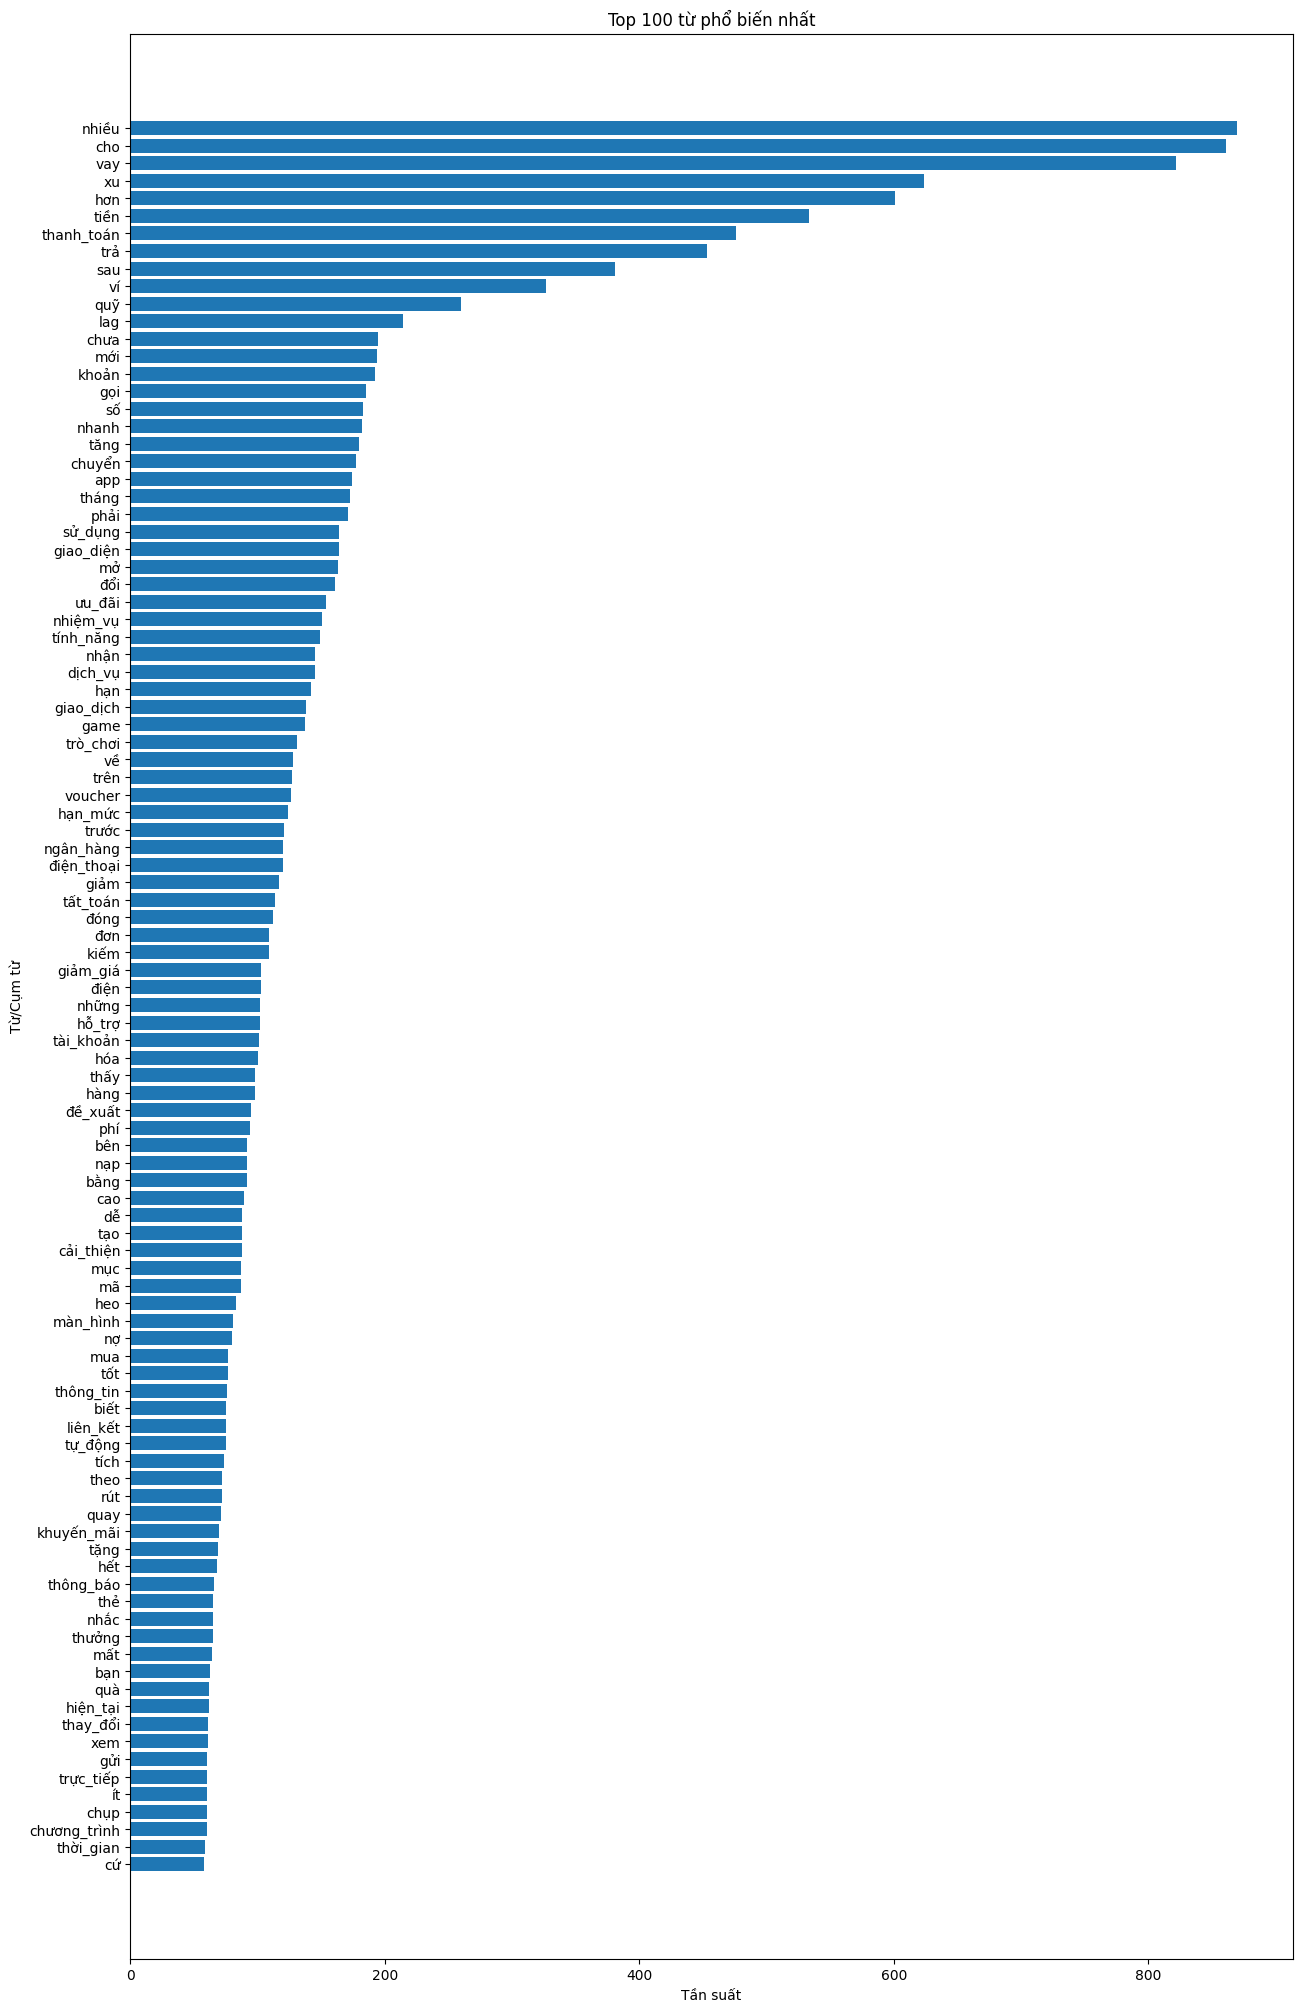

In [659]:
plot_top_ngrams(freq_df, label_col='Từ/Cụm từ', top_n=TOP_N,
                title="Top 100 từ phổ biến nhất")

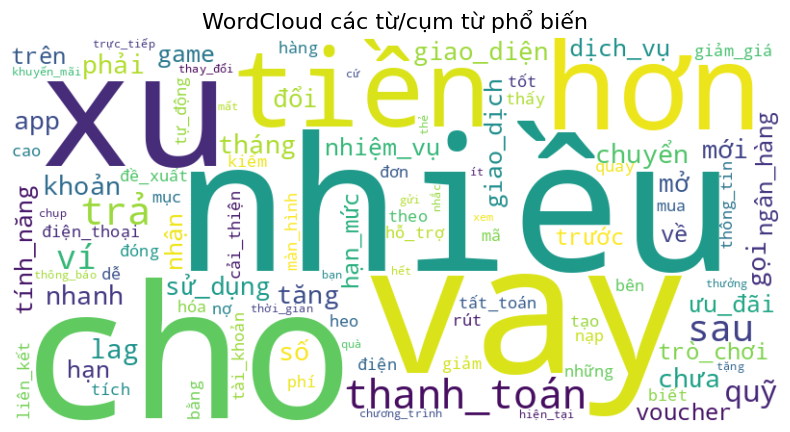

In [660]:
freq_dict = dict(zip(freq_df['Từ/Cụm từ'], freq_df['Tần suất']))
plot_wordcloud(freq_dict, title="WordCloud các từ/cụm từ phổ biến")

## N-gram Analysis

### Bigram

In [663]:
bigram_freq_df = get_top_ngrams(df['processed'], ngram_range=(2,2), top_n=TOP_N)
display(bigram_freq_df)

C:\Users\minhn\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,Cụm từ,Tần suất
0,trả sau,274
1,ví trả,261
2,khoản vay,150
3,cho vay,136
4,vay nhanh,117
5,chuyển tiền,91
6,kiếm xu,84
7,hóa đơn,80
8,nhiều hơn,70
9,nhiều ưu_đãi,70


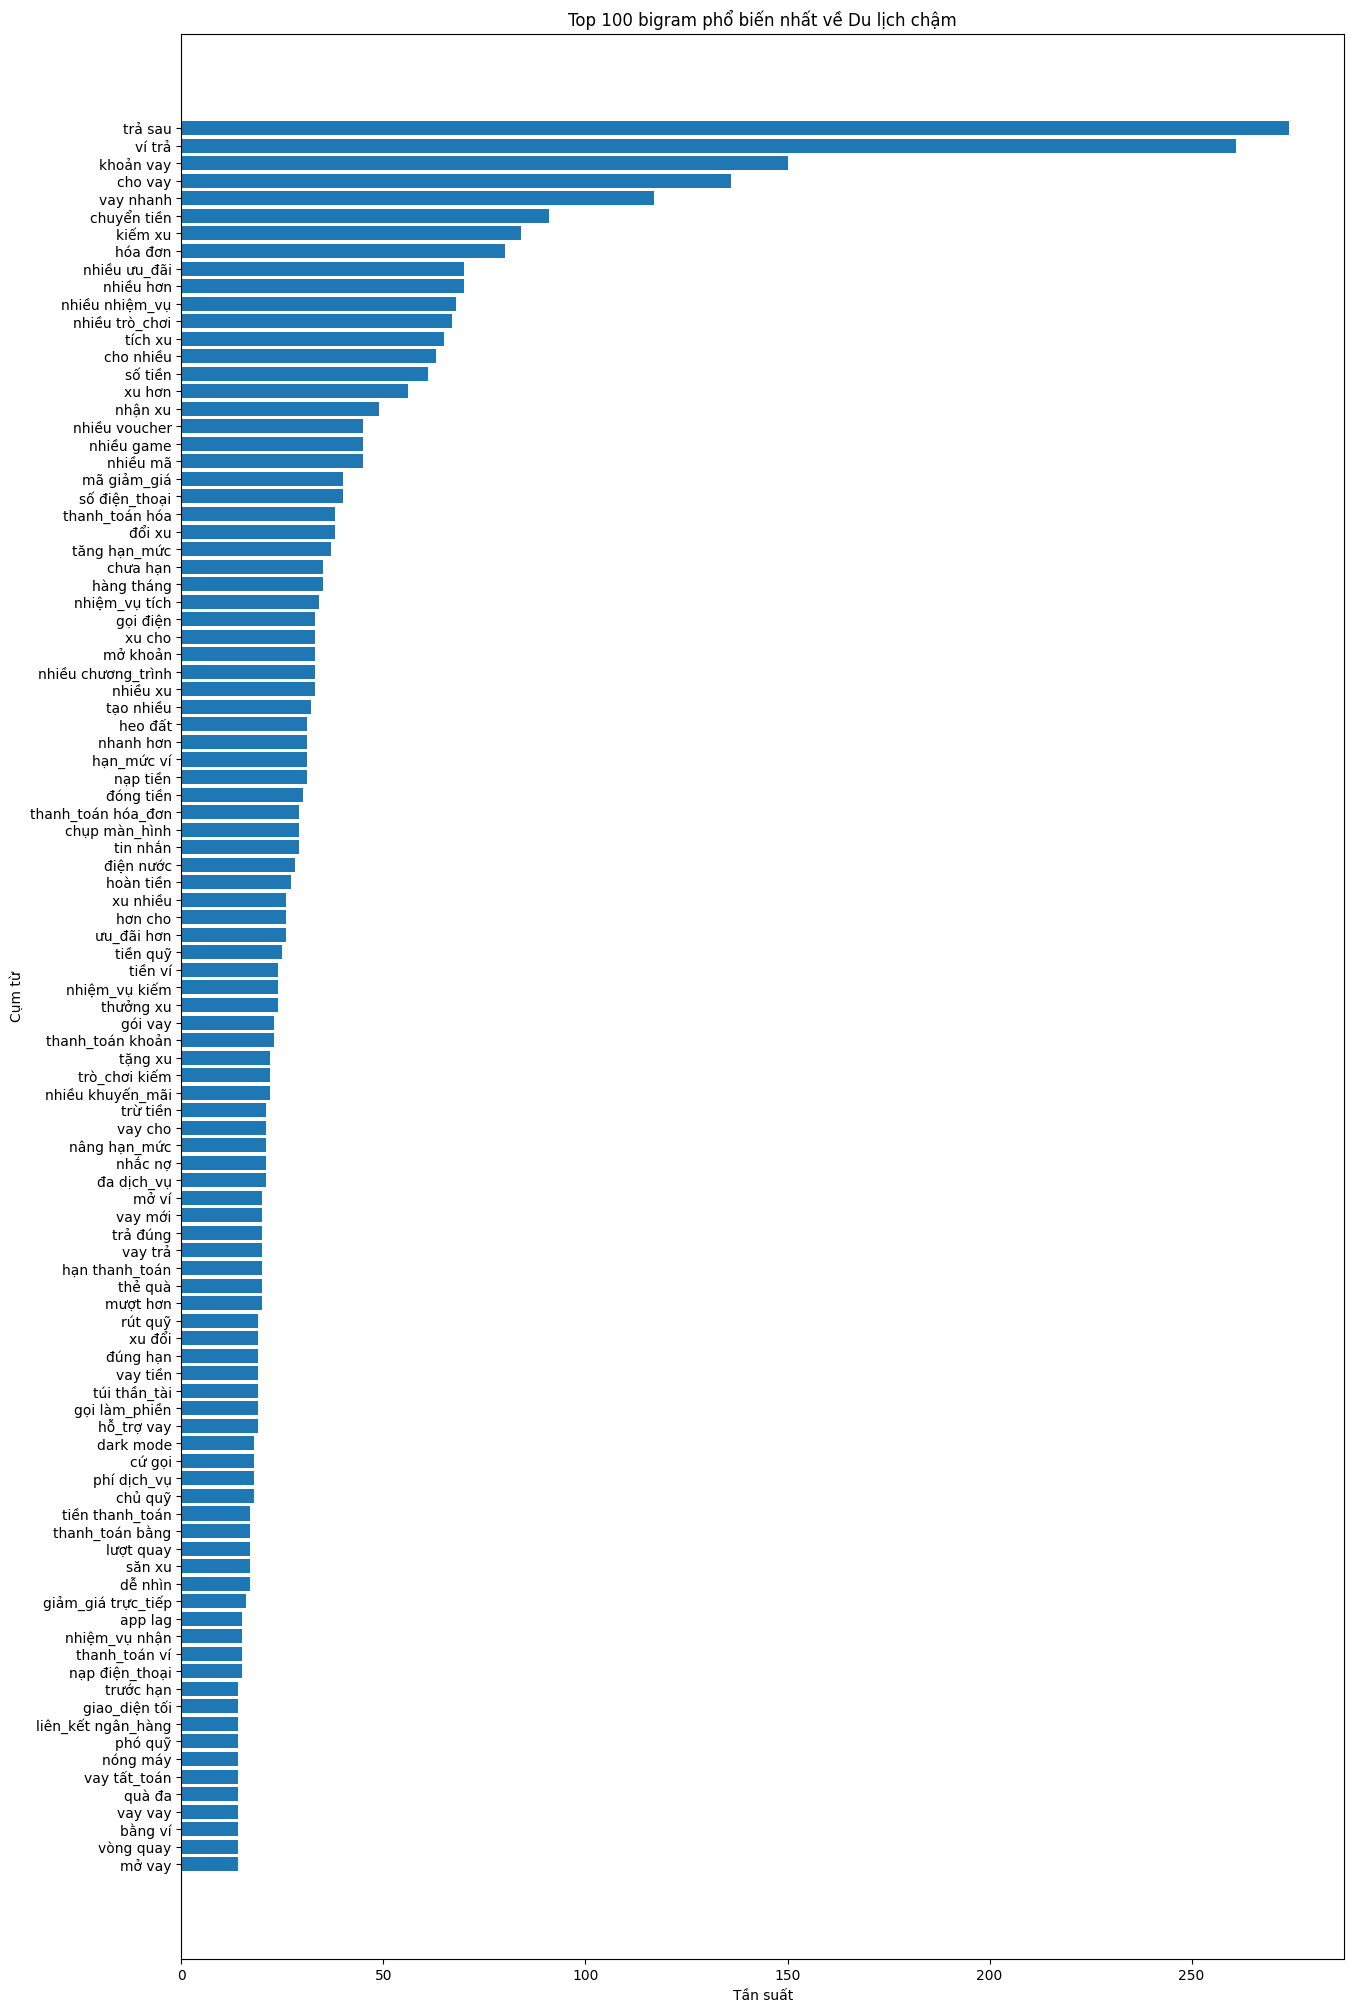

In [ ]:
plot_top_ngrams(bigram_freq_df, label_col='Cụm từ', top_n=TOP_N,
                title="Top 100 bigram phổ biến nhất")

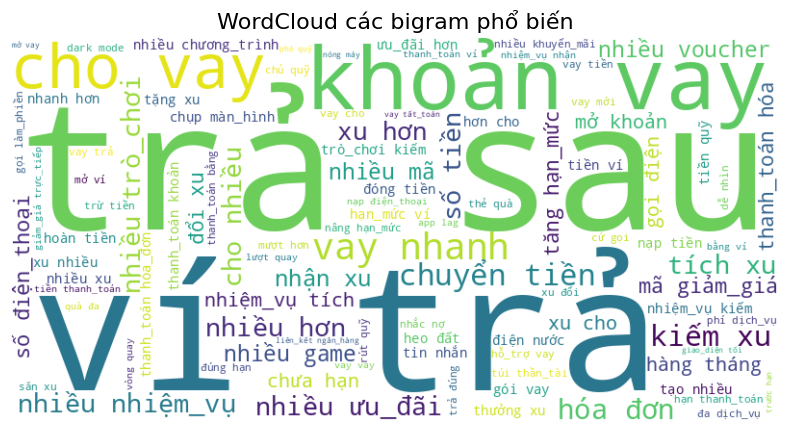

In [665]:
bigram_dict = dict(zip(bigram_freq_df['Cụm từ'], bigram_freq_df['Tần suất']))
plot_wordcloud(bigram_dict, title="WordCloud các bigram phổ biến")

### Trigram

In [667]:
trigram_freq_df = get_top_ngrams(df['processed'], ngram_range=(3,3), top_n=TOP_N)
display(trigram_freq_df)

C:\Users\minhn\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,Cụm từ,Tần suất
0,ví trả sau,241
1,thanh_toán hóa đơn,36
2,nhiệm_vụ tích xu,33
3,mở khoản vay,32
4,hạn_mức ví trả,26
5,nhiều mã giảm_giá,23
6,thanh_toán khoản vay,21
7,tiền ví trả,20
8,nhiệm_vụ kiếm xu,20
9,trò_chơi kiếm xu,19


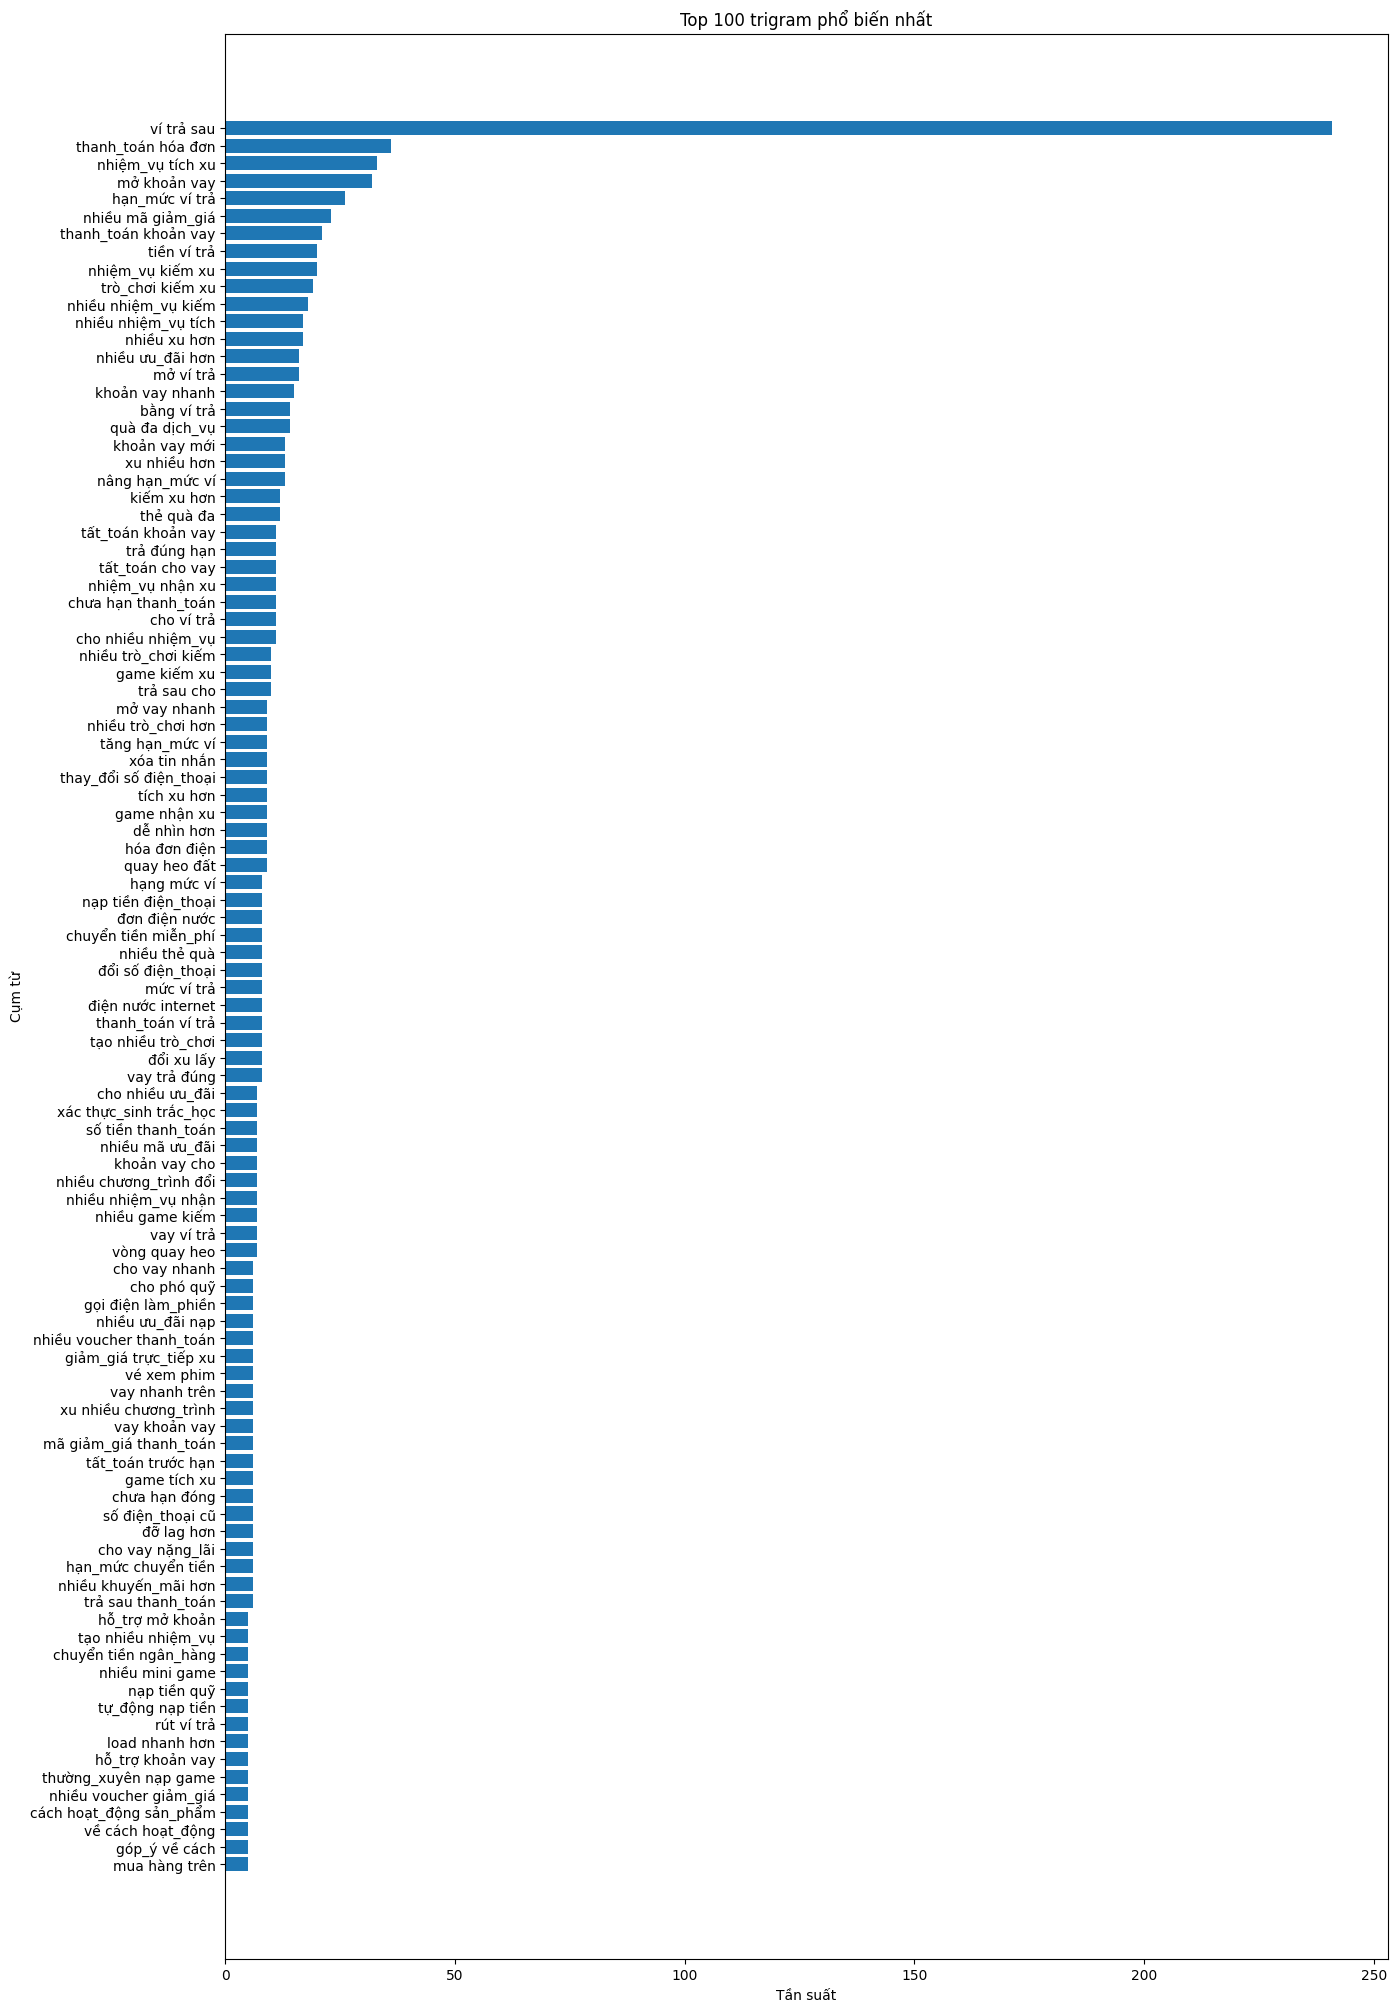

In [668]:
plot_top_ngrams(trigram_freq_df, label_col='Cụm từ', top_n=TOP_N,
                title="Top 100 trigram phổ biến nhất")

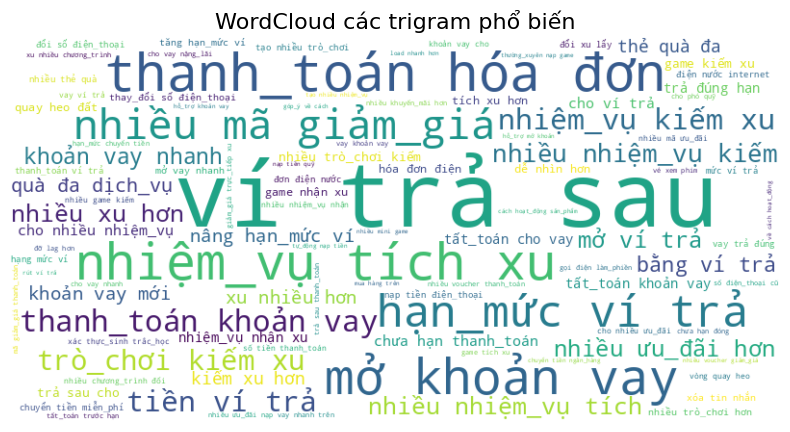

In [669]:
trigram_dict = dict(zip(trigram_freq_df['Cụm từ'], trigram_freq_df['Tần suất']))
plot_wordcloud(trigram_dict, title="WordCloud các trigram phổ biến")

### TF-IDF

In [671]:
df.head()

,contents,clean_text,tokenized,processed
0,nên thông báo khi nào số tiền trong quỹ gần hế...,nên thông báo khi nào số tiền trong quỹ gần hế...,nên thông_báo khi nào số tiền trong quỹ gần hế...,thông_báo số tiền quỹ gần hết theo tháng tuần ...
1,Tài Chính - Bảo Hiểm - Góp ý về cách hoạt động...,tài chính bảo hiểm góp ý về cách hoạt động sản...,tài_chính bảo_hiểm góp_ý về cách hoạt_động sản...,tài_chính bảo_hiểm góp_ý về cách hoạt_động sản...
2,nên bổ sung thêm tính năng quay 1 lúc 10 lần c...,nên bổ sung thêm tính năng quay lúc lần cho vò...,nên bổ_sung thêm tính_năng quay lúc lần cho vò...,bổ_sung tính_năng quay cho vòng quay heo đất t...
3,dễ cho vay hơn,dễ cho vay hơn,dễ cho vay hơn,dễ cho vay hơn
4,tệ lỗi lag,tệ lỗi lag,tệ lỗi lag,tệ lỗi lag


In [672]:
# Số lượng từ/cụm từ trong tập dữ liệu
unique_words = set(" ".join(df["processed"]).split())
num_unique_words = len(unique_words)
print(f"Số lượng từ/cụm từ trong tập dữ liệu: {num_unique_words}")

Số lượng từ/cụm từ trong tập dữ liệu: 4333


In [673]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Khởi tạo TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=num_unique_words,        # Giới hạn số từ vựng
    ngram_range=(1, 3),                   # Sử dụng unigram, bigram, trigram
    min_df=3,                             # Bỏ qua từ xuất hiện ít hơn 3 lần
    max_df=0.85,                          # Bỏ qua từ xuất hiện quá thường xuyên
    stop_words='english',
    sublinear_tf=True,                    # Sử dụng log scaling
    smooth_idf=True,                      # Smooth IDF weights
    norm='l2'                             # L2 normalization
)

In [674]:
def calculate_tf_idf(df: pd.DataFrame):
    # Tính TF-IDF
    documents_cleaned = df['processed'].tolist()
    tfidf_matrix = tfidf_vectorizer.fit_transform(documents_cleaned)

    print(f"Kích thước ma trận TF-IDF: {tfidf_matrix.shape}")
    print(f"Số lượng từ vựng: {len(tfidf_vectorizer.get_feature_names_out())}")

    # Lấy feature names
    feature_names = tfidf_vectorizer.get_feature_names_out()

    return tfidf_matrix, feature_names

# Lấy top các từ quan trọng nhất
def analyze_top_features(tfidf_matrix, feature_names, top_n=20):
    """Phân tích các từ vựng quan trọng nhất"""
    top_words = dict()
    # Tính tổng TF-IDF cho mỗi từ
    feature_scores = np.array(tfidf_matrix.sum(axis=0)).flatten()

    # Lấy top từ vựng
    top_indices = feature_scores.argsort()[-top_n:][::-1]

    for i, idx in enumerate(top_indices):
        print(f"{i+1:2d}. {feature_names[idx]:20s}: {feature_scores[idx]:.4f}")
        top_words[feature_names[idx]] = feature_scores[idx]

    return top_words

Kích thước ma trận TF-IDF: (3999, 2896)
Số lượng từ vựng: 2896
 1. vay                 : 179.0280
 2. nhiều               : 134.5580
 3. cho                 : 120.0796
 4. xu                  : 113.1649
 5. hơn                 : 100.5793
 6. lag                 : 88.5581
 7. tiền                : 80.8509
 8. trả                 : 73.7218
 9. thanh_toán          : 70.3960
10. sau                 : 64.2684
11. ví                  : 58.2784
12. trả sau             : 52.9055
13. ví trả              : 49.7126
14. nhanh               : 46.7150
15. cho vay             : 46.1820
16. ví trả sau          : 46.1196
17. game                : 43.5497
18. giao_diện           : 43.2681
19. ưu_đãi              : 42.8526
20. tăng                : 41.3203
21. khoản               : 40.2696
22. app                 : 40.1872
23. trò_chơi            : 40.1657
24. chuyển              : 39.8288
25. quỹ                 : 39.7584
26. mở                  : 39.7246
27. nhiệm_vụ            : 38.5511
28. chưa      

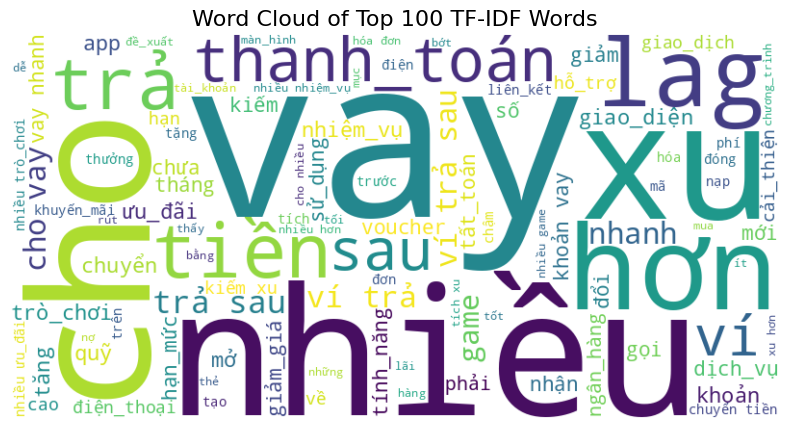

In [675]:
tfidf_matrix, feature_names = calculate_tf_idf(df)
top_words = analyze_top_features(tfidf_matrix, feature_names, TOP_N)
plot_wordcloud(top_words=top_words, title=f"Word Cloud of Top {TOP_N} TF-IDF Words")

# Topic Modeling

## LDA (Latent Dirichlet Allocation)

In [678]:
df.head()

,contents,clean_text,tokenized,processed
0,nên thông báo khi nào số tiền trong quỹ gần hế...,nên thông báo khi nào số tiền trong quỹ gần hế...,nên thông_báo khi nào số tiền trong quỹ gần hế...,thông_báo số tiền quỹ gần hết theo tháng tuần ...
1,Tài Chính - Bảo Hiểm - Góp ý về cách hoạt động...,tài chính bảo hiểm góp ý về cách hoạt động sản...,tài_chính bảo_hiểm góp_ý về cách hoạt_động sản...,tài_chính bảo_hiểm góp_ý về cách hoạt_động sản...
2,nên bổ sung thêm tính năng quay 1 lúc 10 lần c...,nên bổ sung thêm tính năng quay lúc lần cho vò...,nên bổ_sung thêm tính_năng quay lúc lần cho vò...,bổ_sung tính_năng quay cho vòng quay heo đất t...
3,dễ cho vay hơn,dễ cho vay hơn,dễ cho vay hơn,dễ cho vay hơn
4,tệ lỗi lag,tệ lỗi lag,tệ lỗi lag,tệ lỗi lag


In [679]:
df['tokens'] = df['processed'].apply(lambda x: x.split())
display(df.head())

,contents,clean_text,tokenized,processed,tokens
0,nên thông báo khi nào số tiền trong quỹ gần hế...,nên thông báo khi nào số tiền trong quỹ gần hế...,nên thông_báo khi nào số tiền trong quỹ gần hế...,thông_báo số tiền quỹ gần hết theo tháng tuần ...,"[thông_báo, số, tiền, quỹ, gần, hết, theo, thá..."
1,Tài Chính - Bảo Hiểm - Góp ý về cách hoạt động...,tài chính bảo hiểm góp ý về cách hoạt động sản...,tài_chính bảo_hiểm góp_ý về cách hoạt_động sản...,tài_chính bảo_hiểm góp_ý về cách hoạt_động sản...,"[tài_chính, bảo_hiểm, góp_ý, về, cách, hoạt_độ..."
2,nên bổ sung thêm tính năng quay 1 lúc 10 lần c...,nên bổ sung thêm tính năng quay lúc lần cho vò...,nên bổ_sung thêm tính_năng quay lúc lần cho vò...,bổ_sung tính_năng quay cho vòng quay heo đất t...,"[bổ_sung, tính_năng, quay, cho, vòng, quay, he..."
3,dễ cho vay hơn,dễ cho vay hơn,dễ cho vay hơn,dễ cho vay hơn,"[dễ, cho, vay, hơn]"
4,tệ lỗi lag,tệ lỗi lag,tệ lỗi lag,tệ lỗi lag,"[tệ, lỗi, lag]"


In [680]:
data_words = df['tokens'].tolist()
# tạo từ điển
id2word = corpora.Dictionary(data_words)
# tạo corpus
corpus = [id2word.doc2bow(text) for text in data_words]

print(f"\nData words: {data_words}")
print(f"\nDictionary (id2word): {id2word}")
print(f"\nCorpus: {corpus}")


Data words: [['thông_báo', 'số', 'tiền', 'quỹ', 'gần', 'hết', 'theo', 'tháng', 'tuần', 'yêu_cầu', 'nạp', 'tiền', 'cho', 'quỹ', 'tháng', 'tuần', 'treat_quỹ', 'hũ', 'chi_tiêu', 'tháng'], ['tài_chính', 'bảo_hiểm', 'góp_ý', 'về', 'cách', 'hoạt_động', 'sản_phẩm'], ['bổ_sung', 'tính_năng', 'quay', 'cho', 'vòng', 'quay', 'heo', 'đất', 'tiết_kiệm', 'thời_gian'], ['dễ', 'cho', 'vay', 'hơn'], ['tệ', 'lỗi', 'lag'], ['mở_rộng', 'mua', 'thẻ_cào', 'bằng', 'ví', 'trả', 'sau', 'giới_hạn'], ['giảm', 'xu_đổi', 'vuocher', 'xuống', 'cho', 'nhiệm_vụ', 'tương_đối', 'dễ', 'cho', 'khách', 'dễ_tích', 'xu'], ['giao_diện', 'mới', 'hơn'], ['vừa', 'trả', 'vay', 'từ_chối', 'bh', 'vay', 'ddc'], ['vay', 'nhanh', 'lãi', 'cao', 'sau'], ['giai_quyêt', 'app', 'chỵa', 'nhanh', 'hơn'], ['chủ_tài_khoản', 'tự', 'thay_đổi', 'giao_diện'], ['tính_năng', 'chia', 'thông_tin', 'thanh_toán', 'hóa', 'đơn', 'theo', 'dạng', 'text', 'qr_code', 'trường_hợp', 'chia_sẻ', 'thông_tin', 'cho', 'người_thân', 'ví_dụ', 'vợ', 'hỏi', 'tiền', 'họ

In [681]:
from gensim.models import CoherenceModel

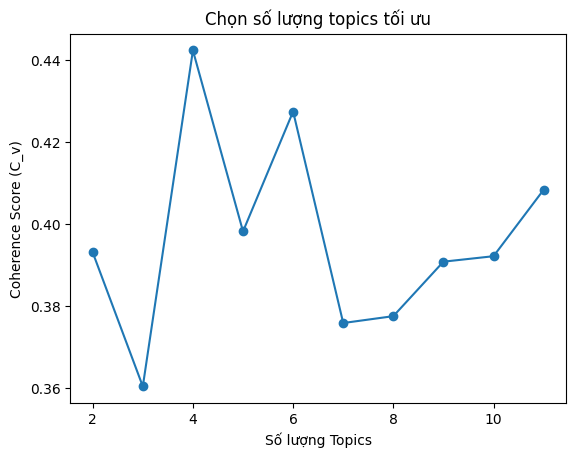

Num Topics = 2 --> Coherence Score = 0.3931
Num Topics = 3 --> Coherence Score = 0.3605
Num Topics = 4 --> Coherence Score = 0.4423
Num Topics = 5 --> Coherence Score = 0.3982
Num Topics = 6 --> Coherence Score = 0.4274
Num Topics = 7 --> Coherence Score = 0.3759
Num Topics = 8 --> Coherence Score = 0.3776
Num Topics = 9 --> Coherence Score = 0.3909
Num Topics = 10 --> Coherence Score = 0.3922
Num Topics = 11 --> Coherence Score = 0.4084


In [701]:
# hàm tìm số lượng topics tối ưu
def compute_coherence_values(dictionary, corpus, texts, start=2, limit=12, step=1):
    coherence_values = []
    model_list = []
    topic_range = range(start, limit, step)

    for num_topics in topic_range:
        lda_model = gensim.models.LdaMulticore(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=100,
            chunksize=100,
            passes=10,
            per_word_topics=True
        )

        model_list.append(lda_model)
        coherencemodel = CoherenceModel(
            model=lda_model, texts=texts, dictionary=dictionary, coherence='c_v'
        )
        coherence_values.append(coherencemodel.get_coherence())

    return model_list, coherence_values, topic_range


# tìm số lượng topics tối ưu
model_list, coherence_values, topic_range = compute_coherence_values(
    dictionary=id2word, corpus=corpus, texts=data_words, start=2, limit=12, step=1
)

# vẽ biểu đồ coherence score
plt.plot(topic_range, coherence_values, marker="o")
plt.xlabel("Số lượng Topics")
plt.ylabel("Coherence Score (C_v)")
plt.title("Chọn số lượng topics tối ưu")
plt.show()

# in kết quả
for m, cv in zip(topic_range, coherence_values):
    print(f"Num Topics = {m} --> Coherence Score = {cv:.4f}")

In [703]:
# huấn luyện mô hình LDA với số lượng topic tối ưu
lda_model = gensim.models.LdaMulticore(
    corpus=corpus,
    id2word=id2word,
    num_topics=6,
    random_state=100,
    chunksize=100,
    passes=10,
    per_word_topics=True
)

# đánh giá mô hình cuối cùng
perplexity = lda_model.log_perplexity(corpus)
coherence_model_lda = CoherenceModel(model=lda_model, texts=data_words, dictionary=id2word, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()

print("\n====== ĐÁNH GIÁ MÔ HÌNH LDA (TỐI ƯU) ======")
print(f"Perplexity: {perplexity:.4f}")
print(f"Coherence Score (C_v): {coherence_lda:.4f}")


====== ĐÁNH GIÁ MÔ HÌNH LDA (TỐI ƯU) ======
Perplexity: -7.0051
Coherence Score (C_v): 0.4068


In [704]:
# Các topic và từ vựng thu được sau huấn luyện

topics = lda_model.print_topics(num_words=10)
for topic in topics:
    print(topic)

(0, '0.095*"nhiều" + 0.078*"xu" + 0.047*"hơn" + 0.030*"cho" + 0.019*"ưu_đãi" + 0.019*"nhiệm_vụ" + 0.017*"trò_chơi" + 0.017*"game" + 0.014*"kiếm" + 0.014*"đổi"')
(1, '0.039*"trả" + 0.036*"sau" + 0.032*"ví" + 0.030*"tiền" + 0.025*"chuyển" + 0.016*"tháng" + 0.014*"quỹ" + 0.013*"thanh_toán" + 0.013*"ngân_hàng" + 0.012*"cho"')
(2, '0.019*"hơn" + 0.017*"app" + 0.014*"giao_diện" + 0.011*"dịch_vụ" + 0.010*"dễ" + 0.010*"lag" + 0.009*"về" + 0.009*"đặt" + 0.008*"mua" + 0.008*"thẻ"')
(3, '0.105*"vay" + 0.041*"cho" + 0.030*"trả" + 0.022*"khoản" + 0.022*"nhanh" + 0.018*"sau" + 0.016*"ví" + 0.016*"mở" + 0.016*"tất_toán" + 0.014*"hạn_mức"')
(4, '0.026*"gọi" + 0.024*"lag" + 0.022*"thanh_toán" + 0.017*"cho" + 0.015*"chưa" + 0.015*"hạn" + 0.014*"tiền" + 0.014*"giao_dịch" + 0.012*"đóng" + 0.010*"màn_hình"')
(5, '0.022*"tiền" + 0.021*"quỹ" + 0.021*"số" + 0.017*"cho" + 0.013*"thanh_toán" + 0.011*"phải" + 0.011*"tài_khoản" + 0.010*"mới" + 0.010*"điện_thoại" + 0.008*"tính_năng"')


In [705]:
# trực quan hóa kết quả
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

vis_data = gensimvis.prepare(lda_model, corpus, id2word, mds="mmds", R=30)
pyLDAvis.display(vis_data)

# lưu file kết quả
# pyLDAvis.save_html(vis_data, 'lda_visualization.html')

In [709]:
# Phân loại chủ đề cho từng content

def find_main_topic(model, corpus_doc):
    topic_distribution = model.get_document_topics(corpus_doc, minimum_probability=0.0)
    main_topic = sorted(topic_distribution, key=lambda x: x[1], reverse=True)[0]
    return main_topic[0], main_topic[1]

main_topics = [find_main_topic(lda_model, doc) for doc in corpus]
df['main_topic_id'] = [item[0] for item in main_topics]
df['topic_contribution'] = [item[1] for item in main_topics]

In [711]:
df.head(10)

,contents,clean_text,tokenized,processed,tokens,main_topic_id,topic_contribution
0,nên thông báo khi nào số tiền trong quỹ gần hế...,nên thông báo khi nào số tiền trong quỹ gần hế...,nên thông_báo khi nào số tiền trong quỹ gần hế...,thông_báo số tiền quỹ gần hết theo tháng tuần ...,"[thông_báo, số, tiền, quỹ, gần, hết, theo, thá...",1,0.960037
1,Tài Chính - Bảo Hiểm - Góp ý về cách hoạt động...,tài chính bảo hiểm góp ý về cách hoạt động sản...,tài_chính bảo_hiểm góp_ý về cách hoạt_động sản...,tài_chính bảo_hiểm góp_ý về cách hoạt_động sản...,"[tài_chính, bảo_hiểm, góp_ý, về, cách, hoạt_độ...",2,0.895605
2,nên bổ sung thêm tính năng quay 1 lúc 10 lần c...,nên bổ sung thêm tính năng quay lúc lần cho vò...,nên bổ_sung thêm tính_năng quay lúc lần cho vò...,bổ_sung tính_năng quay cho vòng quay heo đất t...,"[bổ_sung, tính_năng, quay, cho, vòng, quay, he...",3,0.923519
3,dễ cho vay hơn,dễ cho vay hơn,dễ cho vay hơn,dễ cho vay hơn,"[dễ, cho, vay, hơn]",0,0.449151
4,tệ lỗi lag,tệ lỗi lag,tệ lỗi lag,tệ lỗi lag,"[tệ, lỗi, lag]",4,0.790488
5,mở rộng mua thẻ cào bằng ví trả sau ko giới hạn,mở rộng mua thẻ cào bằng ví trả sau ko giới hạn,mở_rộng mua thẻ_cào bằng ví trả sau ko giới_hạn,mở_rộng mua thẻ_cào bằng ví trả sau giới_hạn,"[mở_rộng, mua, thẻ_cào, bằng, ví, trả, sau, gi...",1,0.906514
6,nên giảm xu đổi vuocher xuống.Cho làm nhiệm vụ...,nên giảm xu đổi vuocher xuống cho làm nhiệm vụ...,nên giảm xu_đổi vuocher xuống cho làm nhiệm_vụ...,giảm xu_đổi vuocher xuống cho nhiệm_vụ tương_đ...,"[giảm, xu_đổi, vuocher, xuống, cho, nhiệm_vụ, ...",0,0.690998
7,mong momo có giao diện mới hơn,mong momo có giao diện mới hơn,mong momo có giao_diện mới hơn,giao_diện mới hơn,"[giao_diện, mới, hơn]",0,0.787667
8,tại sao vừa trả xong vay lại bị từ chối bh k v...,tại sao vừa trả xong vay lại bị từ chối bh k v...,tại_sao vừa trả xong vay lại bị từ_chối bh k v...,vừa trả vay từ_chối bh vay ddc,"[vừa, trả, vay, từ_chối, bh, vay, ddc]",3,0.894615
9,"vay nhanh này lãi cao quá, sẽ không có lần sau.",vay nhanh này lãi cao quá sẽ không có lần sau,vay nhanh này lãi cao quá sẽ không có lần sau,vay nhanh lãi cao sau,"[vay, nhanh, lãi, cao, sau]",3,0.860877
